In [2]:
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

# Transformer Memory Optimization Lab

This notebook implements and benchmarks 5 training regimes:
1. Baseline (FP32)
2. BF16 Mixed Precision
3. FlashAttention v2
4. Windowed Attention
5. Gradient Checkpointing

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.checkpoint import checkpoint
from datasets import load_dataset
from collections import Counter
import math
import time
import gc
import re
from tqdm import tqdm
import matplotlib.pyplot as plt
from flash_attn import flash_attn_qkvpacked_func

## 1. Configuration & Setup

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


torch.manual_seed(42)

VOCAB_SIZE = 33278
SEQ_LEN = 2048
EMBED_DIM = 512
N_HEADS = 8
N_LAYERS = 6
DROPOUT = 0.1

Using device: cuda


## 2. Data Processing (WikiText-2)
Adapted from previous assignment

In [5]:
def basic_english_tokenizer(text: str):
    text = text.lower()
    return re.findall(r"[\w']+|[.,!?;=]", text)


def build_vocab(dataset):
    counter = Counter()
    for item in tqdm(dataset["train"], desc="Building Vocab"):
        text = item.get("text", "")
        counter.update(basic_english_tokenizer(text))

    min_freq = 3
    vocab_list = ["<unk>", "<pad>", "<eos>"] + [
        t for t, c in counter.items() if c >= min_freq
    ]
    word_to_idx = {t: i for i, t in enumerate(vocab_list)}
    return word_to_idx, vocab_list


def process_data(dataset, word_to_idx, seq_len):
    unk_idx = word_to_idx["<unk>"]
    eos_idx = word_to_idx["<eos>"]

    data = []
    for item in tqdm(dataset, desc="Tokenizing"):
        text = item.get("text", "")
        if not text.strip():
            continue
        tokens = basic_english_tokenizer(text)
        indices = [word_to_idx.get(t, unk_idx) for t in tokens] + [eos_idx]
        data.extend(indices)

    num_tokens = (len(data) // seq_len) * seq_len
    data = torch.tensor(data[:num_tokens], dtype=torch.long)
    return data


print("Loading WikiText-2...")
dataset = load_dataset("wikitext", "wikitext-2-v1")
word_to_idx, idx_to_word = build_vocab(dataset)
VOCAB_SIZE = len(word_to_idx)
print(f"Vocab Size: {VOCAB_SIZE}")

train_flat = process_data(dataset["train"], word_to_idx, SEQ_LEN)
val_flat = process_data(dataset["validation"], word_to_idx, SEQ_LEN)

print(f"Train Tokens: {len(train_flat)}")
print(f"Val Tokens: {len(val_flat)}")

Loading WikiText-2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Building Vocab: 100%|██████████| 36718/36718 [00:01<00:00, 21013.15it/s]


Vocab Size: 28751


Tokenizing: 100%|██████████| 3760/3760 [00:00<00:00, 19953.29it/s]

Train Tokens: 1996800
Val Tokens: 208896


## 3. Model Definition (Custom GPT with Swappable Attention)

In [6]:
class CausalSelfAttention(nn.Module):
    def __init__(
        self, embed_dim, n_heads, dropout, use_flash=False, window_size=(-1, -1)
    ):
        super().__init__()
        assert embed_dim % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = embed_dim // n_heads
        self.use_flash = use_flash
        self.window_size = window_size

        self.c_attn = nn.Linear(embed_dim, 3 * embed_dim, bias=False)
        self.c_proj = nn.Linear(embed_dim, embed_dim, bias=False)

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.size()

        qkv = self.c_attn(x)

        qkv = qkv.view(B, T, 3, self.n_heads, self.head_dim)

        if self.use_flash:
            y = flash_attn_qkvpacked_func(
                qkv,
                dropout_p=self.attn_dropout.p if self.training else 0.0,
                softmax_scale=None,
                causal=True,
                window_size=self.window_size,
            )
            y = y.reshape(B, T, C)

        else:
            q, k, v = qkv.unbind(dim=2)
            q = q.transpose(1, 2)
            k = k.transpose(1, 2)
            v = v.transpose(1, 2)

            mask = None
            is_causal = True

            if self.window_size != (-1, -1):
                lookback = self.window_size[0]
                if 0 < lookback < T:
                    row_idx = torch.arange(T, device=x.device).unsqueeze(1)
                    col_idx = torch.arange(T, device=x.device).unsqueeze(0)

                    mask = (row_idx >= col_idx) & ((row_idx - col_idx) <= lookback)

                    is_causal = False

            y = F.scaled_dot_product_attention(
                q,
                k,
                v,
                attn_mask=mask,
                dropout_p=self.attn_dropout.p if self.training else 0.0,
                is_causal=is_causal,
            )

            y = y.transpose(1, 2).contiguous().view(B, T, C)

        y = self.resid_dropout(self.c_proj(y))
        return y


class MLP(nn.Module):
    def __init__(self, embed_dim, dropout):
        super().__init__()
        self.c_fc = nn.Linear(embed_dim, 4 * embed_dim)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class Block(nn.Module):
    def __init__(
        self,
        embed_dim,
        n_heads,
        dropout,
        use_flash,
        window_size,
        use_checkpointing=False,
    ):
        super().__init__()
        self.ln_1 = nn.LayerNorm(embed_dim)
        self.attn = CausalSelfAttention(
            embed_dim, n_heads, dropout, use_flash, window_size
        )
        self.ln_2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, dropout)
        self.use_checkpointing = use_checkpointing

    def forward(self, x):
        def _inner_forward(x_in):
            x_res = x_in + self.attn(self.ln_1(x_in))
            x_out = x_res + self.mlp(self.ln_2(x_res))
            return x_out

        if self.use_checkpointing and self.training:
            return checkpoint(_inner_forward, x, use_reentrant=False)
        else:
            return _inner_forward(x)


class GPT(nn.Module):
    def __init__(
        self,
        vocab_size,
        seq_len,
        embed_dim,
        n_heads,
        n_layers,
        dropout,
        use_flash=False,
        window_size=(-1, -1),
        use_checkpointing=False,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.position_embedding = nn.Embedding(seq_len, embed_dim)
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList(
            [
                Block(
                    embed_dim,
                    n_heads,
                    dropout,
                    use_flash,
                    window_size,
                    use_checkpointing,
                )
                for _ in range(n_layers)
            ]
        )

        self.ln_f = nn.LayerNorm(embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocab_size, bias=False)

        self.token_embedding.weight = self.lm_head.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)

        x = self.token_embedding(idx) + self.position_embedding(pos)
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss

## 4. Training Utilities & Profiling

In [7]:
def get_model(config):
    return GPT(
        vocab_size=VOCAB_SIZE,
        seq_len=SEQ_LEN,
        embed_dim=EMBED_DIM,
        n_heads=N_HEADS,
        n_layers=N_LAYERS,
        dropout=DROPOUT,
        use_flash=config["use_flash"],
        window_size=config["window_size"],
        use_checkpointing=config["use_checkpointing"],
    ).to(device)


def train_one_epoch(model, optimizer, data_flat, batch_size, config):
    model.train()

    n_batches = len(data_flat) // (batch_size * SEQ_LEN)
    data_len = n_batches * batch_size * SEQ_LEN
    data = data_flat[:data_len].view(batch_size, -1)

    total_loss = 0
    start_time = time.time()

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

    step_times = []

    num_steps = data.size(1) // SEQ_LEN

    scaler = torch.cuda.amp.GradScaler(enabled=config["use_amp"])

    pbar = tqdm(range(num_steps), desc=f"Training ({config['name']})", leave=False)

    for i in pbar:
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        step_start = time.time()

        inputs = data[:, i * SEQ_LEN : (i + 1) * SEQ_LEN].to(device)
        targets = data[:, i * SEQ_LEN + 1 : (i + 1) * SEQ_LEN + 1].to(device)

        if targets.size(1) != SEQ_LEN:
            continue

        optimizer.zero_grad(set_to_none=True)

        dtype_ctx = torch.bfloat16 if config["dtype"] == "bf16" else torch.float32

        with torch.cuda.amp.autocast(dtype=dtype_ctx, enabled=config["use_amp"]):
            logits, loss = model(inputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        step_end = time.time()
        step_times.append(step_end - step_start)
        total_loss += loss.item()

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_time = time.time() - start_time
    avg_step_time = sum(step_times) / len(step_times) if step_times else 0

    peak_mem = 0
    if torch.cuda.is_available():
        peak_mem = torch.cuda.max_memory_allocated() / (1024**2)

    avg_loss = total_loss / num_steps
    ppl = math.exp(avg_loss) if avg_loss < 100 else float("inf")

    return {
        "loss": avg_loss,
        "ppl": ppl,
        "epoch_time": epoch_time,
        "avg_step_time": avg_step_time * 1000,
        "peak_mem_mb": peak_mem,
    }


def evaluate(model, data_flat, batch_size, config):
    model.eval()

    n_batches = len(data_flat) // (batch_size * SEQ_LEN)
    data_len = n_batches * batch_size * SEQ_LEN
    data = data_flat[:data_len].view(batch_size, -1)

    num_steps = data.size(1) // SEQ_LEN
    total_loss = 0

    with torch.no_grad():
        for i in range(num_steps):
            inputs = data[:, i * SEQ_LEN : (i + 1) * SEQ_LEN].to(device)
            targets = data[:, i * SEQ_LEN + 1 : (i + 1) * SEQ_LEN + 1].to(device)

            if targets.size(1) != SEQ_LEN:
                continue

            dtype_ctx = torch.bfloat16 if config["dtype"] == "bf16" else torch.float32

            with torch.cuda.amp.autocast(dtype=dtype_ctx, enabled=config["use_amp"]):
                logits, loss = model(inputs, targets)

            total_loss += loss.item()

    avg_loss = total_loss / num_steps if num_steps > 0 else 0
    ppl = math.exp(avg_loss) if avg_loss < 100 else float("inf")
    return ppl


def find_max_batch_size(config, data_flat):
    print(f"Finding max batch size for {config['name']}...")
    bs = 1
    max_working_bs = 1

    while True:
        try:
            gc.collect()
            torch.cuda.empty_cache()

            model = get_model(config)
            optimizer = optim.AdamW(model.parameters(), lr=0.0003)
            scaler = torch.cuda.amp.GradScaler(enabled=config["use_amp"])

            model.train()

            inputs = torch.randint(0, VOCAB_SIZE, (bs, SEQ_LEN)).to(device)
            targets = torch.randint(0, VOCAB_SIZE, (bs, SEQ_LEN)).to(device)

            dtype_ctx = torch.bfloat16 if config["dtype"] == "bf16" else torch.float32

            for _ in range(3):
                optimizer.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(
                    dtype=dtype_ctx, enabled=config["use_amp"]
                ):
                    _, loss = model(inputs, targets)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            print(f"  BS={bs} successful.")
            max_working_bs = bs
            del model, optimizer, scaler

            bs *= 2

            if bs > 512:
                break

        except RuntimeError as e:
            if "out of memory" in str(e):
                print(f"  BS={bs} failed (OOM). Max working BS is {max_working_bs}.")
                break
            else:
                raise e

    return max_working_bs

## 5. Experiment Definitions

In [8]:
experiments = [
    {
        "name": "1. Baseline (FP32)",
        "use_amp": False,
        "dtype": "fp32",
        "use_flash": False,
        "window_size": (-1, -1),
        "use_checkpointing": False,
    },
    {
        "name": "2. BF16 Mixed Precision",
        "use_amp": True,
        "dtype": "bf16",
        "use_flash": False,
        "window_size": (-1, -1),
        "use_checkpointing": False,
    },
    {
        "name": "3. FlashAttention v2 (BF16)",
        "use_amp": True,
        "dtype": "bf16",
        "use_flash": True,
        "window_size": (-1, -1),
        "use_checkpointing": False,
    },
    {
        "name": "4. Windowed Attention (Window=64)",
        "use_amp": True,
        "dtype": "bf16",
        "use_flash": True,
        "window_size": (64, 64),  # Sliding window
        "use_checkpointing": False,
    },
    {
        "name": "5. Gradient Checkpointing (BF16)",
        "use_amp": True,
        "dtype": "bf16",
        "use_flash": False,  # Keep flash off to isolate checkpointing effect
        "window_size": (-1, -1),
        "use_checkpointing": True,
    },
]

## 6. Main Execution Loop

In [9]:
results = []

for exp_config in experiments:
    print(f"\n{'=' * 60}")
    print(f"Running Experiment: {exp_config['name']}")
    print(f"{'=' * 60}")

    max_bs = find_max_batch_size(exp_config, train_flat)

    print(f"Max Batch Size determined: {max_bs}")

    gc.collect()
    torch.cuda.empty_cache()

    model = get_model(exp_config)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

    print("Training for 1 epoch...")
    stats = train_one_epoch(model, optimizer, train_flat, max_bs, exp_config)

    print("Evaluating on Validation Set...")
    val_ppl = evaluate(model, val_flat, max_bs, exp_config)
    print(f"Validation PPL: {val_ppl:.2f}")

    result_entry = {
        "Technique": exp_config["name"],
        "Max BS": max_bs,
        "Peak Mem (MB)": f"{stats['peak_mem_mb']:.2f}",
        "Step Time (ms)": f"{stats['avg_step_time']:.2f}",
        "Epoch Time (s)": f"{stats['epoch_time']:.2f}",
        "Train PPL": f"{stats['ppl']:.2f}",
        "Val PPL": f"{val_ppl:.2f}",
    }
    results.append(result_entry)
    print(result_entry)

    del model, optimizer
    gc.collect()
    torch.cuda.empty_cache()


Running Experiment: 1. Baseline (FP32)
Finding max batch size for 1. Baseline (FP32)...
  BS=1 successful.
  BS=2 successful.
  BS=4 successful.
  BS=8 successful.
  BS=16 failed (OOM). Max working BS is 8.
Max Batch Size determined: 8
Training for 1 epoch...


Evaluating on Validation Set...
Validation PPL: 273.84
{'Technique': '1. Baseline (FP32)', 'Max BS': 8, 'Peak Mem (MB)': '10851.40', 'Step Time (ms)': '587.83', 'Epoch Time (s)': '70.72', 'Train PPL': '956.06', 'Val PPL': '273.84'}

Running Experiment: 2. BF16 Mixed Precision
Finding max batch size for 2. BF16 Mixed Precision...
  BS=1 successful.
  BS=2 successful.
  BS=4 successful.
  BS=8 successful.
  BS=16 successful.
  BS=32 failed (OOM). Max working BS is 16.
Max Batch Size determined: 16
Training for 1 epoch...


Evaluating on Validation Set...
Validation PPL: 193.11
{'Technique': '2. BF16 Mixed Precision', 'Max BS': 16, 'Peak Mem (MB)': '15035.46', 'Step Time (ms)': '407.02', 'Epoch Time (s)': '24.10', 'Train PPL': '1298.08', 'Val PPL': '193.11'}

Running Experiment: 3. FlashAttention v2 (BF16)
Finding max batch size for 3. FlashAttention v2 (BF16)...
  BS=1 successful.
  BS=2 successful.
  BS=4 successful.
  BS=8 successful.
  BS=16 successful.
  BS=32 failed (OOM). Max working BS is 16.
Max Batch Size determined: 16
Training for 1 epoch...


Evaluating on Validation Set...
Validation PPL: 188.88
{'Technique': '3. FlashAttention v2 (BF16)', 'Max BS': 16, 'Peak Mem (MB)': '15035.46', 'Step Time (ms)': '410.41', 'Epoch Time (s)': '24.30', 'Train PPL': '1305.49', 'Val PPL': '188.88'}

Running Experiment: 4. Windowed Attention (Window=64)
Finding max batch size for 4. Windowed Attention (Window=64)...
  BS=1 successful.
  BS=2 successful.
  BS=4 successful.
  BS=8 successful.
  BS=16 successful.
  BS=32 failed (OOM). Max working BS is 16.
Max Batch Size determined: 16
Training for 1 epoch...


Evaluating on Validation Set...
Validation PPL: 194.97
{'Technique': '4. Windowed Attention (Window=64)', 'Max BS': 16, 'Peak Mem (MB)': '15035.46', 'Step Time (ms)': '379.03', 'Epoch Time (s)': '22.45', 'Train PPL': '1342.53', 'Val PPL': '194.97'}

Running Experiment: 5. Gradient Checkpointing (BF16)
Finding max batch size for 5. Gradient Checkpointing (BF16)...
  BS=1 successful.
  BS=2 successful.
  BS=4 successful.
  BS=8 successful.
  BS=16 successful.
  BS=32 failed (OOM). Max working BS is 16.
Max Batch Size determined: 16
Training for 1 epoch...


Evaluating on Validation Set...
Validation PPL: 194.45
{'Technique': '5. Gradient Checkpointing (BF16)', 'Max BS': 16, 'Peak Mem (MB)': '11725.33', 'Step Time (ms)': '471.63', 'Epoch Time (s)': '27.91', 'Train PPL': '1337.98', 'Val PPL': '194.45'}


## 7. Final Report & Tables


Final Comparison Table
| Technique                         |   Max BS |   Peak Mem (MB) |   Step Time (ms) |   Epoch Time (s) |   Train PPL |   Val PPL |
|:----------------------------------|---------:|----------------:|-----------------:|-----------------:|------------:|----------:|
| 1. Baseline (FP32)                |        8 |         10851.4 |           587.83 |            70.72 |      956.06 |    273.84 |
| 2. BF16 Mixed Precision           |       16 |         15035.5 |           407.02 |            24.1  |     1298.08 |    193.11 |
| 3. FlashAttention v2 (BF16)       |       16 |         15035.5 |           410.41 |            24.3  |     1305.49 |    188.88 |
| 4. Windowed Attention (Window=64) |       16 |         15035.5 |           379.03 |            22.45 |     1342.53 |    194.97 |
| 5. Gradient Checkpointing (BF16)  |       16 |         11725.3 |           471.63 |            27.91 |     1337.98 |    194.45 |


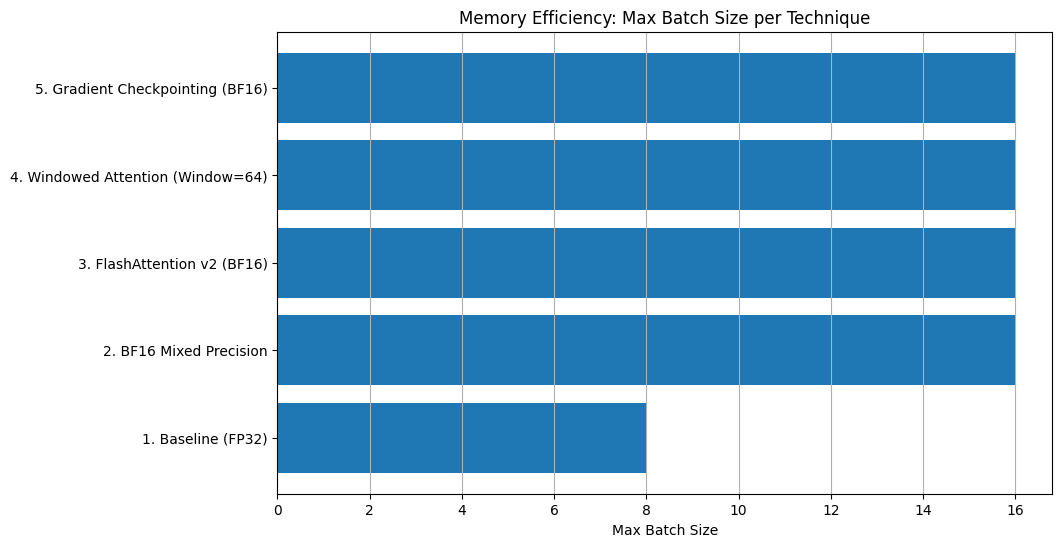

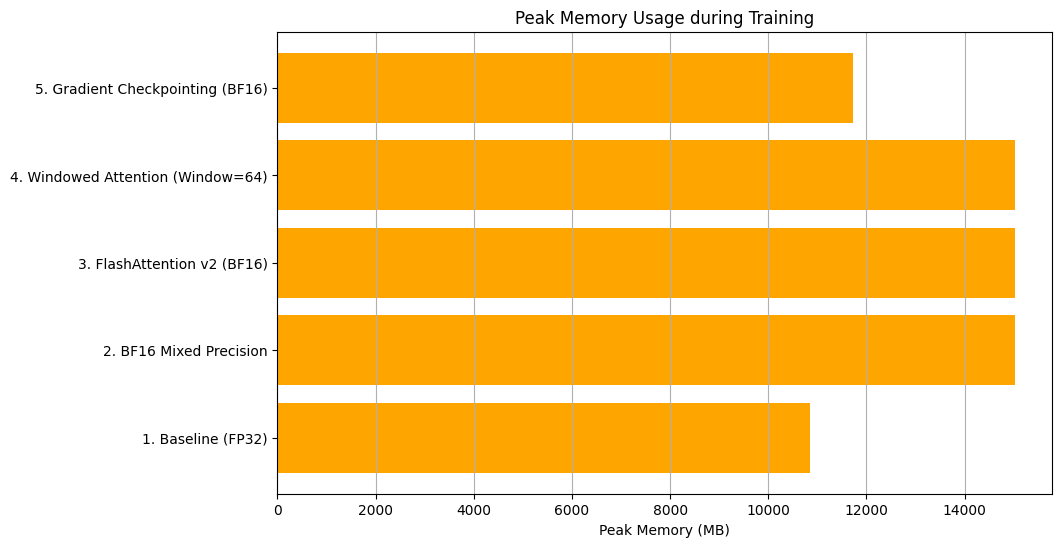

In [10]:
import pandas as pd

df = pd.DataFrame(results)
print("\nFinal Comparison Table")
print(df.to_markdown(index=False))

plt.figure(figsize=(10, 6))
plt.barh(df["Technique"], df["Max BS"])
plt.xlabel("Max Batch Size")
plt.title("Memory Efficiency: Max Batch Size per Technique")
plt.grid(axis="x")
plt.show()

plt.figure(figsize=(10, 6))
peak_mem_vals = [float(x) for x in df["Peak Mem (MB)"]]
plt.barh(df["Technique"], peak_mem_vals, color="orange")
plt.xlabel("Peak Memory (MB)")
plt.title("Peak Memory Usage during Training")
plt.grid(axis="x")
plt.show()